#Versuni - E-Commerce Analytics Case Study
# Praveen Kumar RAJARAMAN
Thursday-April 23, 2026

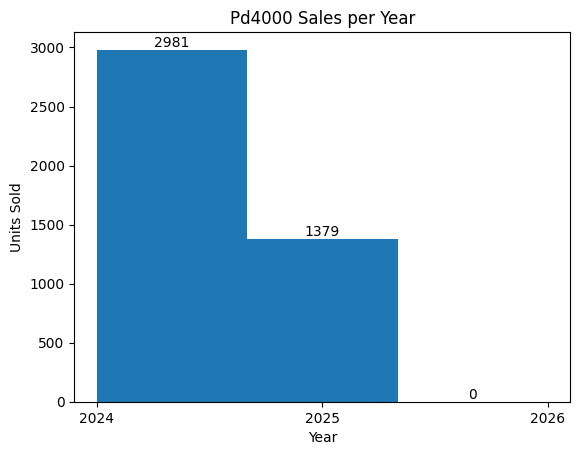

In [66]:
#Histogram Analysis:
#1.	Plot a histogram showing the number of units sold for product "Pd4000" for the years 2024 and 2025.

import pandas as pd #libraries
import matplotlib.pyplot as plt

df = pd.read_csv("eCommerce API dataset.csv")   #read data

df = df[df["Product ID"] == "Pd4000"]

df["Year"] = df["Year-Week"].str[:4]

sales_per_year = df.groupby("Year")["Units Sold"].sum()

n, bins, patches = plt.hist(sales_per_year.index, weights=sales_per_year.values, bins=len(sales_per_year))

for patch, value in zip(patches, sales_per_year.values):
    plt.text(patch.get_x() + patch.get_width()/2, patch.get_height(), int(value), ha='center', va='bottom')

plt.title("Pd4000 Sales per Year")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.show()

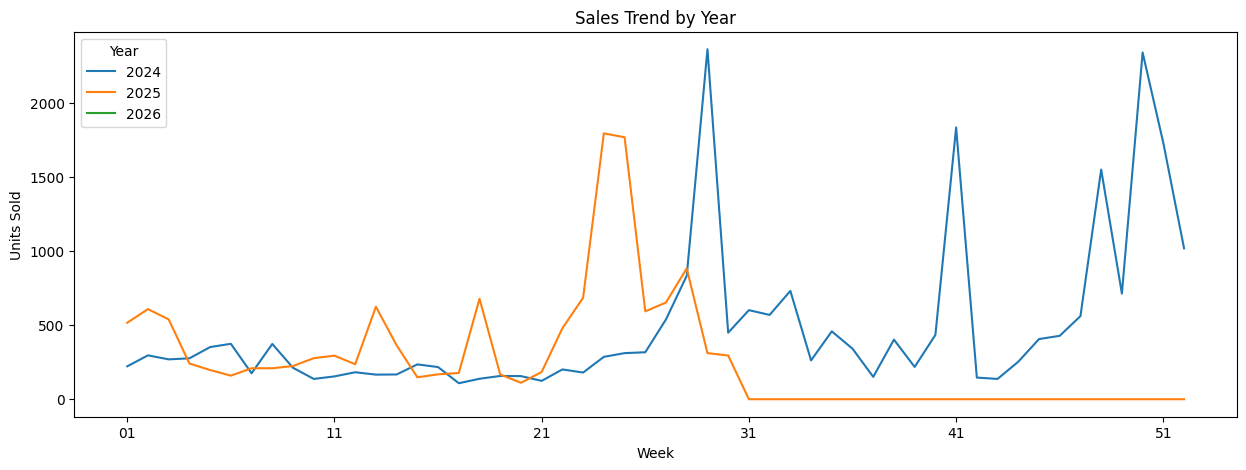

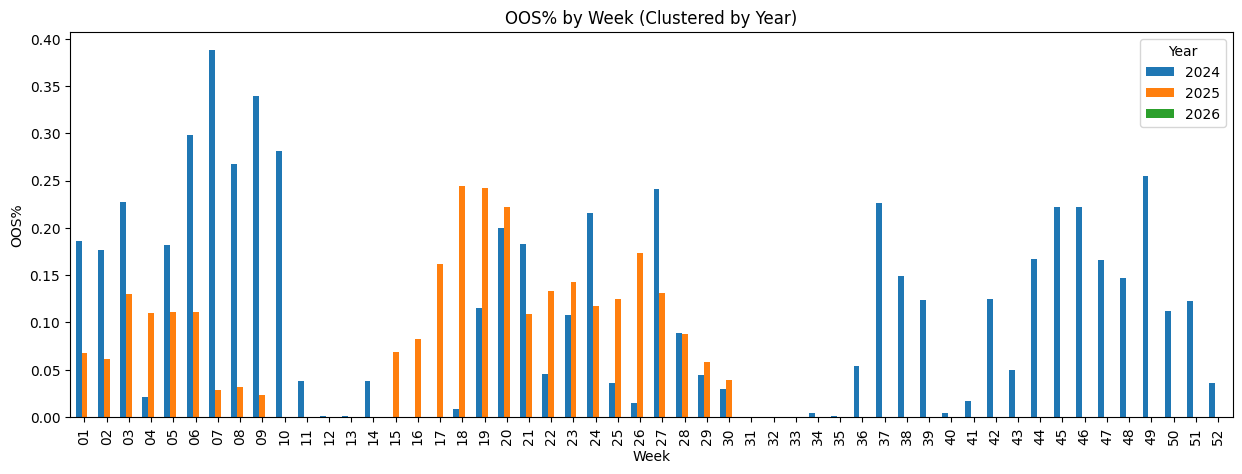

In [81]:
#Year-on-Year Performance Comparison:
#2.	 Plot the total Sales trend with distinct lines for each year present in the dataset. Do the same in a different chart for OOS%.
#

df["Year"] = df["Year-Week"].str[:4]
df["Week"] = df["Year-Week"].str[-2:]

sales = df.groupby(["Year","Week"])["Units Sold"].sum().unstack(0)

sales.plot(figsize=(15,5))

plt.title("Sales Trend by Year")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.show()

print()

#OOS%

df["Year"] = df["Year-Week"].str[:4]
df["Week"] = df["Year-Week"].str[-2:]

oos = df.groupby(["Week","Year"])["OOS%"].mean().unstack()

oos.plot(kind="bar", width=0.8, figsize=(15,5))

plt.title("OOS% by Week (Clustered by Year)")
plt.xlabel("Week")
plt.ylabel("OOS%")
plt.show()

In [82]:
#Product Sales Ranking:
#3.	For each year (2024 and 2025), create a ranking of products based on total sales.
#Now add also Conversion% and Traffic in the same table, what are the products with highest Traffic or Conversion%?

import pandas as pd

df = pd.read_csv("eCommerce API dataset.csv")

df["Year"] = df["Year-Week"].str[:4]

data = df.groupby(["Year","Product ID"])[["Units Sold","Conversion %"]].sum().reset_index()

data = data[data["Year"].isin(["2024","2025"])]

data["Rank"] = data.groupby("Year")["Units Sold"].rank(ascending=False, method="dense")

data["Traffic"] = data["Units Sold"] / data["Conversion %"]

# reordering columns
data = data[["Year","Product ID","Units Sold","Rank","Conversion %","Traffic"]]

print(data.sort_values(["Year","Rank"]).reset_index(drop=True).to_string(index=False)+ "\n")

# Getting top 3 products with highest Conversion% per year
top_conversion = (data.sort_values(["Year", "Conversion %"], ascending=[True, False]).groupby("Year").head(3))

print("Top products by Conversion% per year:")
print(top_conversion[["Product ID","Conversion %","Year"]].to_string(index=False))

Year Product ID  Units Sold  Rank  Conversion %      Traffic
2024     Pd1000      9050.0   1.0      0.642691 14081.409702
2024     Pd2000      6293.0   2.0      0.845122  7446.260637
2024     Pd3000      3137.0   3.0      0.661058  4745.425665
2024     Pd4000      2981.0   4.0      1.509440  1974.905244
2024     Pd5000      2739.0   5.0      0.791786  3459.266702
2024     Pd9000       470.0   6.0      0.401085  1171.822407
2024     Pd6000       290.0   7.0      0.342895   845.739550
2024     Pd7000       224.0   8.0      0.323356   692.735285
2024     Pd8000        66.0   9.0      0.264681   249.356614
2025     Pd2000      5403.0   1.0      0.663941  8137.768606
2025     Pd1000      2456.0   2.0      0.381588  6436.253711
2025     Pd9000      1702.0   3.0      0.546603  3113.779110
2025     Pd4000      1379.0   4.0      0.479487  2875.992895
2025     Pd5000       921.0   5.0      0.267533  3442.565282
2025     Pd3000       602.0   6.0      0.287647  2092.842425
2025     Pd8000       46

In [83]:
#Event Calendar Analysis:
#Utilize the Holiday dataset in the .txt file as a map for your weekly data.
#4.	Identify which Event generated the most product page Traffic in 2025. Is this different from what happened in 2024?

ev = pd.read_csv("Event Calendar.txt")

df["Year"] = df["Year-Week"].str[:4]
df["Week"] = df["Year-Week"].str[-2:].astype(int)
ev["Week"] = ev["Week Nr"].str.extract(r'(\d+)').astype(int)

data = df.merge(ev, on=["Year","Week"], how="left")
data["Traffic"] = data["Units Sold"] / (data["Conversion %"].replace(0, 0.01) / 100)

res = data.groupby(["Year","Event Name"])["Traffic"].sum().reset_index()

final = res.sort_values(["Year","Traffic"], ascending=[True,False]).dropna().groupby("Year").head(1)

print(final.to_string(index=False) + "\n")

print("Is this different from what happened in 2024?\nYes, in 2024 top-traffic driving event is Black Friday but in 2025 it's Epiphany. This indicates the shift in demand pattern.")



Year   Event Name      Traffic
2024 Black Friday 1.482570e+07
2025     Epiphany 3.048800e+06

Is this different from what happened in 2024?
Yes, in 2024 top-traffic driving event is Black Friday but in 2025 it's Epiphany. This indicates the shift in demand pattern.


In [84]:
#Out of Stock Analysis:
#5.	Calculate the Out Of Stock % for both 2024 and 2025.


df["Year"] = df["Year-Week"].str[:4]

oos = df.groupby("Year")["OOS%"].mean().reset_index()
oos = oos[oos["Year"].isin(["2024","2025"])]

oos = oos.rename(columns={"OOS%":"Out of Stock"})

# Convert to percentage
#oos["Out of Stock"] = (oos["Out of Stock"] * 100).round(2).astype(str) + " %"

print(oos.to_string(index=False))

Year  Out of Stock
2024      0.113480
2025      0.092187


In [85]:
#6.For 2025, determine which Events experienced the highest Out Of Stock%.

df["Year"] = df["Year-Week"].str[:4]
df["Week"] = df["Year-Week"].str[-2:].astype(int)
ev["Week"] = ev["Week Nr"].str.extract(r'(\d+)').astype(int)

data = df.merge(ev, on=["Year","Week"], how="left")

data = data[data["Year"] == "2025"]

res = data.groupby("Event Name")["OOS%"].mean().reset_index()

res = res.dropna()
res = res[res["OOS%"] > 0]
res = res.sort_values("OOS%", ascending=False)

res = res.rename(columns={"OOS%":"Out of Stock"})
res["Out of Stock"] = (res["Out of Stock"] * 100).round(2).astype(str) + "%"

print(res.to_string(index=False))

       Event Name Out of Stock
       Labour Day       24.42%
    Easter Monday       16.22%
    Easter Sunday        8.28%
         Epiphany        6.79%
   New Year's Day        6.79%
Holiday in France        6.17%


In [75]:
#Sales Threshold Analysis:
#7.	For each Year-Week entry, create Year, Month, and Quarter columns.

# convert Year-Week to date (start of week)
df["Date"] = pd.to_datetime(df["Year-Week"] + "-1", format="%Y-%W-%w")

# extract fields
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

print(df[["Year-Week","Year","Month","Quarter"]].head(15).to_string(index=False))


Year-Week  Year  Month  Quarter
  2024-01  2024      1        1
  2024-02  2024      1        1
  2024-03  2024      1        1
  2024-04  2024      1        1
  2024-05  2024      1        1
  2024-06  2024      2        1
  2024-07  2024      2        1
  2024-08  2024      2        1
  2024-09  2024      2        1
  2024-10  2024      3        1
  2024-11  2024      3        1
  2024-12  2024      3        1
  2024-13  2024      3        1
  2024-14  2024      4        2
  2024-15  2024      4        2


In [92]:
#8.	For each Year and Quarter combination, count the number of instances when any product’s monthly sales exceeded 1,000 units.
#Rank the products in terms of how many times this threshold has been met.

df_q = df.copy()

df_q["Year"] = df_q["Year-Week"].str[:4].astype(int)
df_q["Week"] = df_q["Year-Week"].str[-2:].astype(int)

df_q["Month"] = (((df_q["Week"] - 1) // 4) % 12) + 1
df_q["Quarter"] = ((df_q["Month"] - 1) // 3) + 1

m = df_q.groupby(["Year","Quarter","Month","Product ID"])["Units Sold"].sum().reset_index()

m = m[m["Units Sold"] > 1000]

res = m.groupby(["Year","Quarter","Product ID"]).size().reset_index(name="Count")

res["Rank"] = res.groupby(["Year","Quarter"])["Count"].rank(ascending=False, method="dense").astype(int)

print(res.sort_values(["Year","Quarter","Rank"]).to_string(index=False))

 Year  Quarter Product ID  Count  Rank
 2024        1     Pd1000      1     1
 2024        1     Pd3000      1     1
 2024        3     Pd2000      3     1
 2024        4     Pd1000      2     1
 2025        1     Pd1000      1     1
 2025        2     Pd2000      1     1
 2025        3     Pd2000      1     1
